# 군집분석 실습 (붓꽃 품종 데이터)

---

## 📌 실습 개요

- **데이터**: IRIS.CSV (변수: 5개, 자료 수: 150개)
- **목적**: 붓꽃의 꽃잎 및 꽃받침 길이·넓이 자료를 이용하여 군집 분석 실시 및 결과 해석
- **분석 절차**:
  - **STEP 1**: 데이터 구성하기
  - **STEP 2**: 데이터 현황 확인 → 표준화 적용 결정
  - **STEP 3**: 계층형 군집분석 실시 (Ward 방법 적용 및 결과 비교, 군집 프로파일)
  - **STEP 4**: K-평균 군집분석 실시 (군집 평가 해석)

## 라이브러리 임포트

In [5]:
# 데이터 구성: Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Scale 변환: 평균, 표준편차 기준
from sklearn.preprocessing import StandardScaler
# linkage: 계층형 군집분석, dendrogram: 계층구조 나무, fcluster: linkage로부터 얻은 값으로 군집 생성
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# 군집 방법: AgglomerativeClustering(계층형), KMeans(k-평균)
from sklearn.cluster import AgglomerativeClustering, KMeans

# 실루엣(Silhouette) 계수 산출
from sklearn.metrics import silhouette_samples, silhouette_score

import warnings
warnings.filterwarnings('ignore')

#### 그래프 옵션 지정

In [6]:
# 그래프 한글폰트 적용: 맑은 고딕 (Windows) / NanumGothic (Linux)
try:
    matplotlib.rc("font", family="Malgun Gothic")
except:
    matplotlib.rc("font", family="DejaVu Sans")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus=False)

---

## STEP 1: 데이터 구성하기

In [7]:
# IRIS 데이터 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\IRIS.csv")
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---

## STEP 2: 데이터 현황 확인 → 표준화 적용 결정

In [8]:
# 기초 통계량 확인 (변수 간 단위·범위 차이 파악)
df_raw.describe()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# 군집분석에 사용할 수치형 변수만 분리 (SPECIES 제외)
df_feat = df_raw.drop("SPECIES", axis=1)

# 데이터 표준화 (변수 간 스케일 차이가 있으므로 표준화 적용)
scaler = StandardScaler()
df_raw_scaled = scaler.fit_transform(df_feat)

# 위에서부터 자료 5개 확인
df_raw_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [10]:
# 설명 변수: 표준화된 전체 데이터 사용
df_raw_x = df_raw_scaled

---

## STEP 3: 계층형 군집분석 실시

### Ward 방법 적용 및 결과 비교

In [11]:
# 연결: ward, 거리 계산: Euclidean  →  ward ~ Euclidean
Z_ward    = linkage(df_raw_x, method="ward",    metric="euclidean")
# 연결: average, 거리 계산: Euclidean
Z_average = linkage(df_raw_x, method="average", metric="euclidean")

In [12]:
# 군집 생성 결과 확인
Z_ward

array([[1.01000000e+02, 1.42000000e+02, 0.00000000e+00, 2.00000000e+00],
       [7.00000000e+00, 3.90000000e+01, 1.21167870e-01, 2.00000000e+00],
       [1.00000000e+01, 4.80000000e+01, 1.21167870e-01, 2.00000000e+00],
       [9.00000000e+00, 3.40000000e+01, 1.31632184e-01, 2.00000000e+00],
       [0.00000000e+00, 1.70000000e+01, 1.31632184e-01, 2.00000000e+00],
       [1.28000000e+02, 1.32000000e+02, 1.31632184e-01, 2.00000000e+00],
       [1.27000000e+02, 1.38000000e+02, 1.33836265e-01, 2.00000000e+00],
       [2.00000000e+00, 4.70000000e+01, 1.33836265e-01, 2.00000000e+00],
       [8.00000000e+01, 8.10000000e+01, 1.43378956e-01, 2.00000000e+00],
       [1.90000000e+01, 4.60000000e+01, 1.43378956e-01, 2.00000000e+00],
       [1.00000000e+00, 2.50000000e+01, 1.66143388e-01, 2.00000000e+00],
       [1.20000000e+02, 1.43000000e+02, 1.66143388e-01, 2.00000000e+00],
       [1.10000000e+01, 2.40000000e+01, 1.70512281e-01, 2.00000000e+00],
       [4.00000000e+01, 1.54000000e+02, 1.72216546e

Text(0, 0.5, 'Distance')

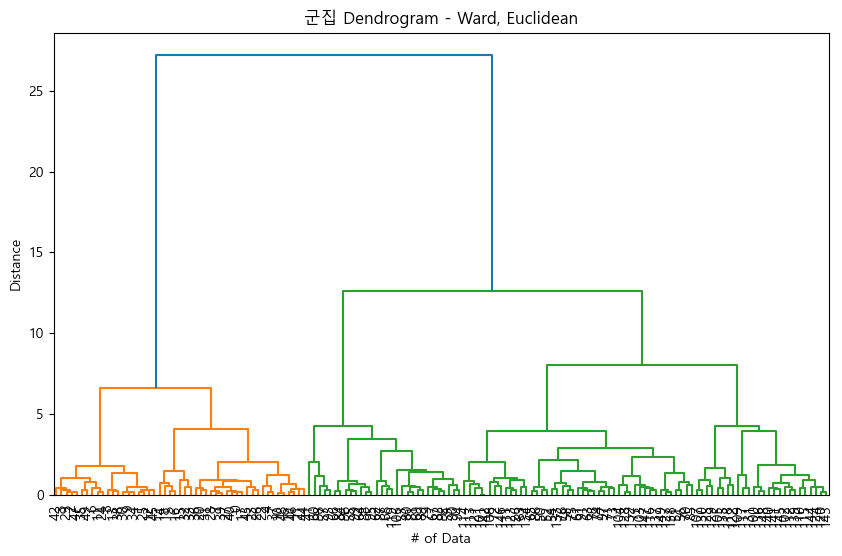

In [13]:
# 덴드로그램 [연결: ward, 거리 계산: Euclidean]
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
dendrogram(Z_ward, leaf_font_size=10, orientation="top")
plt.title("군집 Dendrogram - Ward, Euclidean")
plt.xlabel("# of Data")
plt.ylabel("Distance")

Text(0, 0.5, 'Distance')

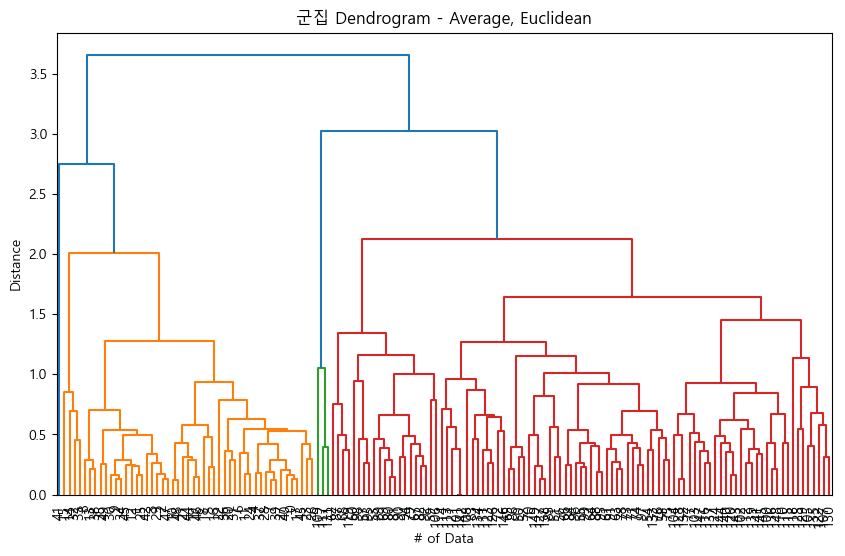

In [14]:
# 덴드로그램 [연결: average, 거리 계산: Euclidean]
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
dendrogram(Z_average, leaf_font_size=10, orientation="top")
plt.title("군집 Dendrogram - Average, Euclidean")
plt.xlabel("# of Data")
plt.ylabel("Distance")

### 군집 프로파일

In [15]:
# linkage 함수를 통해 얻은 Z_ward 행렬 데이터를 이용하여 군집 생성
# 덴드로그램에서 적절한 거리 기준(t=7)을 지정하여 군집 분리
cluster_H = fcluster(Z=Z_ward, t=7, criterion="distance")
# 데이터에 계층형 군집 결과 입력
df_raw["cluster_H"] = cluster_H
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES,cluster_H
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [16]:
# 집계 함수를 이용한 군집별 데이터 요약
df_summary_H = df_raw.drop("SPECIES", axis=1).groupby("cluster_H").agg(["min", "mean", "max"])
# 집계 함수를 이용할 경우 열 이름이 두 줄에 걸쳐 나오므로 한 줄로 변환
level0 = df_summary_H.columns.get_level_values(0)
level1 = df_summary_H.columns.get_level_values(1)
df_summary_H.columns = level0 + "_" + level1
df_summary_H.reset_index(inplace=True)
df_summary_H.round(3)

,cluster_H,SEPAL_LENGTH_min,SEPAL_LENGTH_mean,SEPAL_LENGTH_max,SEPAL_WIDTH_min,SEPAL_WIDTH_mean,SEPAL_WIDTH_max,PETAL_LENGTH_min,PETAL_LENGTH_mean,PETAL_LENGTH_max,PETAL_WIDTH_min,PETAL_WIDTH_mean,PETAL_WIDTH_max
0,1,4.3,5.016,5.8,2.9,3.451,4.4,1.0,1.465,1.9,0.1,0.245,0.6
1,2,4.5,5.530,6.3,2.0,2.567,3.0,1.3,3.930,5.0,0.3,1.207,1.7
2,3,5.6,6.273,7.0,2.5,2.893,3.4,4.0,4.916,5.8,1.2,1.671,2.4
3,4,6.2,7.019,7.9,2.6,3.165,3.8,5.1,5.877,6.9,1.6,2.173,2.5


array([[<Axes: title={'center': 'SEPAL_LENGTH'}, xlabel='cluster_H'>,
        <Axes: title={'center': 'SEPAL_WIDTH'}, xlabel='cluster_H'>],
       [<Axes: title={'center': 'PETAL_LENGTH'}, xlabel='cluster_H'>,
        <Axes: title={'center': 'PETAL_WIDTH'}, xlabel='cluster_H'>]],
      dtype=object)

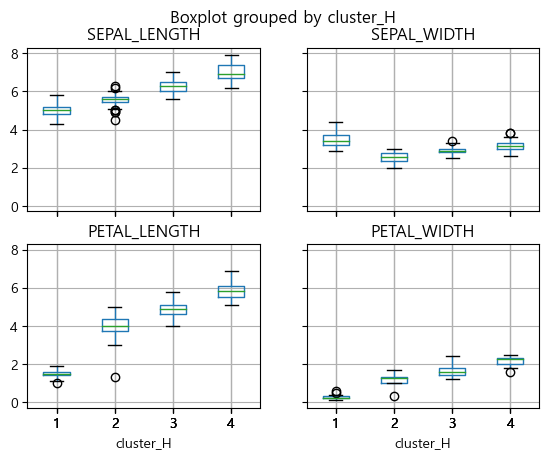

In [17]:
# Boxplot을 활용한 군집별 설명변수 분포
df_raw.boxplot(
    column=["SEPAL_LENGTH", "SEPAL_WIDTH", "PETAL_LENGTH", "PETAL_WIDTH"],
    by="cluster_H"
)

In [18]:
# 군집별 품종(SPECIES) 분포 확인 (교차표)
pd.crosstab(df_raw["cluster_H"], df_raw["SPECIES"])

SPECIES,setosa,versicolor,virginica
cluster_H,,,
1,49,0,0
2,1,27,2
3,0,23,22
4,0,0,26


---

## STEP 4: K-평균 군집분석 실시

### 최적 군집 수 탐색 (Elbow Method)

In [19]:
# 최대 군집 생성 개수
n_iter_cluster = 15
cluster_range = [i + 1 for i in range(n_iter_cluster)]
clus_error = []

for v_n_clus in cluster_range:
    clus = KMeans(v_n_clus, random_state=42)
    clus.fit(df_raw_x)
    # 각 데이터로부터 가장 가까운 군집 중심점까지 거리 제곱합
    clus_error.append(clus.inertia_)

df_error = pd.DataFrame({"NumberofCluster": cluster_range, "Error": clus_error})
df_error.round(3)

,NumberofCluster,Error
0,1,600.000
1,2,222.362
2,3,139.820
3,4,114.093
4,5,90.807
5,6,80.037
6,7,70.720
7,8,62.565
8,9,54.828
9,10,47.801


Text(0, 0.5, 'Sum of Square')

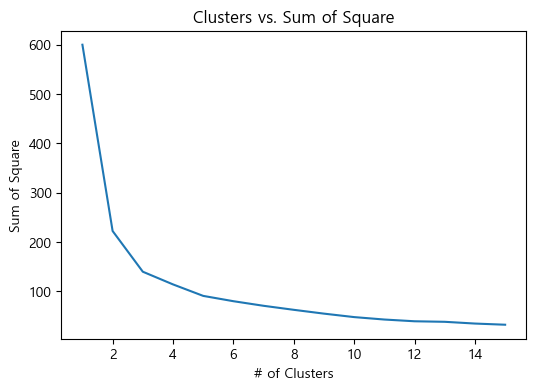

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(df_error["NumberofCluster"], df_error["Error"])
plt.title("Clusters vs. Sum of Square")
plt.xlabel("# of Clusters")
plt.ylabel("Sum of Square")

In [21]:
# Elbow 확인 후 적정 군집 수(3) 선택하여 K-평균 군집 생성
clus = KMeans(3, random_state=42)
clus.fit(df_raw_x)
cluster_KM = [i + 1 for i in clus.labels_]
df_raw["cluster_KM"] = cluster_KM
df_raw.head(10)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES,cluster_H,cluster_KM
0,5.1,3.5,1.4,0.2,setosa,1,2
1,4.9,3.0,1.4,0.2,setosa,1,2
2,4.7,3.2,1.3,0.2,setosa,1,2
3,4.6,3.1,1.5,0.2,setosa,1,2
4,5.0,3.6,1.4,0.2,setosa,1,2
5,5.4,3.9,1.7,0.4,setosa,1,2
6,4.6,3.4,1.4,0.3,setosa,1,2
7,5.0,3.4,1.5,0.2,setosa,1,2
8,4.4,2.9,1.4,0.2,setosa,1,2
9,4.9,3.1,1.5,0.1,setosa,1,2


In [22]:
# 군집별 요약 통계량
df_summary_KM = df_raw.drop(["SPECIES", "cluster_H"], axis=1, inplace=False) \
    .groupby("cluster_KM").agg(["min", "mean", "max"])
level0 = df_summary_KM.columns.get_level_values(0)
level1 = df_summary_KM.columns.get_level_values(1)
df_summary_KM.columns = level0 + "_" + level1
df_summary_KM.reset_index(inplace=True)
df_summary_KM.round(3)

,cluster_KM,SEPAL_LENGTH_min,SEPAL_LENGTH_mean,SEPAL_LENGTH_max,SEPAL_WIDTH_min,SEPAL_WIDTH_mean,SEPAL_WIDTH_max,PETAL_LENGTH_min,PETAL_LENGTH_mean,PETAL_LENGTH_max,PETAL_WIDTH_min,PETAL_WIDTH_mean,PETAL_WIDTH_max
0,1,5.9,6.781,7.9,2.5,3.096,3.8,4.4,5.511,6.9,1.4,1.972,2.5
1,2,4.3,5.006,5.8,2.3,3.428,4.4,1.0,1.462,1.9,0.1,0.246,0.6
2,3,4.9,5.802,6.6,2.0,2.674,3.0,3.0,4.370,5.6,1.0,1.413,2.4


array([[<Axes: title={'center': 'SEPAL_LENGTH'}, xlabel='cluster_KM'>,
        <Axes: title={'center': 'SEPAL_WIDTH'}, xlabel='cluster_KM'>],
       [<Axes: title={'center': 'PETAL_LENGTH'}, xlabel='cluster_KM'>,
        <Axes: title={'center': 'PETAL_WIDTH'}, xlabel='cluster_KM'>]],
      dtype=object)

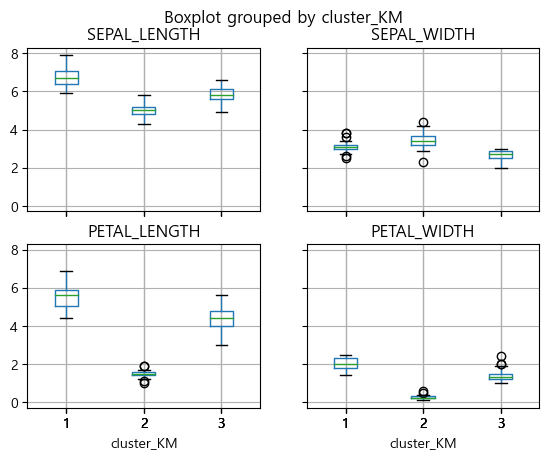

In [23]:
# Boxplot을 활용한 군집별 설명변수 분포
df_raw.boxplot(
    column=["SEPAL_LENGTH", "SEPAL_WIDTH", "PETAL_LENGTH", "PETAL_WIDTH"],
    by="cluster_KM"
)

In [24]:
# 군집별 품종(SPECIES) 분포 확인 (교차표)
pd.crosstab(df_raw["cluster_KM"], df_raw["SPECIES"])

SPECIES,setosa,versicolor,virginica
cluster_KM,,,
1,0,11,36
2,50,0,0
3,0,39,14


---

## 적정 군집 수 결정

### 예제 - 적정 군집 수 결정

sklearn에서 지원하는 AgglomerativeClustering, KMeans (실루엣 계수는 silhouette_score 활용)

In [25]:
# scipy.cluster.hierarchy의 계층형 군집분석은 실루엣 계수 산출 안됨
# 실루엣 계수 산출: sklearn.AgglomerativeClustering(계층형 군집분석)
cls_h = AgglomerativeClustering(n_clusters=2).fit_predict(df_raw_x)  # 군집 수 = 2
sil_score = silhouette_score(df_raw_x, cls_h, metric='euclidean')
print("계층형(군집 수=2) 실루엣 계수 =", format(round(sil_score, 3)))

cls_h = AgglomerativeClustering(n_clusters=3).fit_predict(df_raw_x)  # 군집 수 = 3
sil_score = silhouette_score(df_raw_x, cls_h, metric='euclidean')
print("계층형(군집 수=3) 실루엣 계수 =", format(round(sil_score, 3)))

계층형(군집 수=2) 실루엣 계수 = 0.577
계층형(군집 수=3) 실루엣 계수 = 0.447


In [26]:
# 실루엣 계수 산출: sklearn.KMeans(k-평균 군집분석)
cls_k = KMeans(2, random_state=42).fit_predict(df_raw_x)  # 군집 수 = 2
sil_score = silhouette_score(df_raw_x, cls_k)
print("k-평균(군집 수=2) 실루엣 계수 =", format(round(sil_score, 3)))

cls_k = KMeans(3, random_state=42).fit_predict(df_raw_x)  # 군집 수 = 3
sil_score = silhouette_score(df_raw_x, cls_k)
print("k-평균(군집 수=3) 실루엣 계수 =", format(round(sil_score, 3)))

k-평균(군집 수=2) 실루엣 계수 = 0.582
k-평균(군집 수=3) 실루엣 계수 = 0.46


#### 해석

| 방법 | 군집 수 | 설명 |
|------|---------|------|
| 계층형 | 2 | 군집 수가 적을수록 응집도 ↑ |
| 계층형 | 3 | 실제 품종 수(3)와 일치 |
| K-평균 | 2 | 군집 수가 적을수록 응집도 ↑ |
| K-평균 | 3 | 실루엣 계수 비교하여 최적 선택 |

- 실루엣 계수는 **-1 ~ 1** 사이 값이며, **1에 가까울수록 군집 품질이 좋음**
- 실루엣 계수가 가장 높은 군집 수를 최적 군집 수로 선택

### 참조 - 적정 군집 수 결정

sklearn에서 지원하는 KMeans (실루엣 계수는 silhouette_samples, silhouette_score 활용)

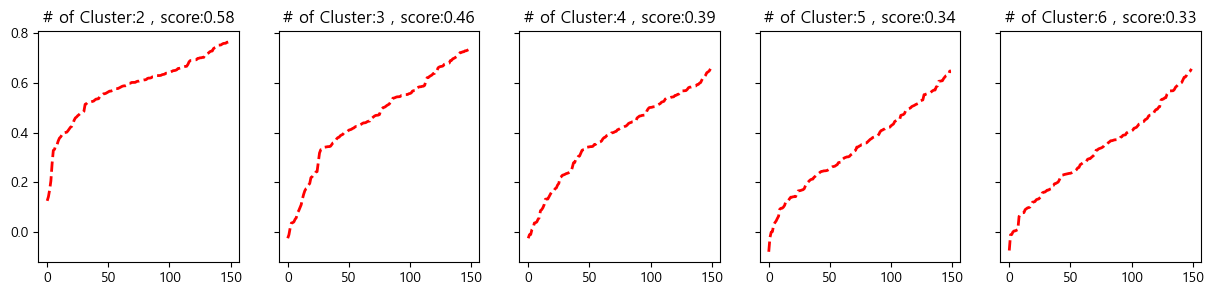

In [27]:
f, axes = plt.subplots(1, 5, sharex=True, sharey=True)
f.set_size_inches(15, 3)

for i, ax in enumerate(axes):
    cluster_nums = KMeans(n_clusters=i + 2, random_state=42).fit_predict(df_raw_x)

    sil_samples = silhouette_samples(df_raw_x, cluster_nums, metric='euclidean')
    sil_score   = silhouette_score(df_raw_x, cluster_nums, metric='euclidean')
    ax.plot(sorted(sil_samples), color='red', linestyle='dashed', linewidth=2)
    ax.set_title("# of Cluster:{} , score:{}".format(round(i + 2), format(round(sil_score, 2))))

plt.show()

### 적정 군집 수 결정

실루엣 계수 점수 / 실루엣 시각화 (SilhouetteVisualizer 방식)

In [28]:
# 실루엣 시각화 함수 정의 (yellowbrick SilhouetteVisualizer 방식과 동일)
def silhouette_visualizer(X, n_clusters, ax, random_state=42):
    km = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    samples = silhouette_samples(X, labels)

    colors = cm.nipy_spectral(np.linspace(0.1, 0.9, n_clusters))
    y_lower = 10
    for i in range(n_clusters):
        ith = sorted(samples[labels == i])
        size = len(ith)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                         facecolor=colors[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i + 1))
        y_lower = y_upper + 10

    ax.axvline(x=score, color='red', linestyle='--')
    ax.set_title(f"n_clusters={n_clusters}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster label")
    return score

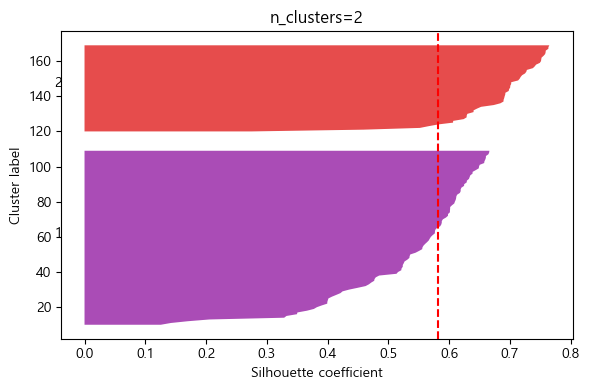

실루엣 계수 = 0.5818


In [ ]:
# 군집 수 = 2
fig, ax = plt.subplots(figsize=(6, 4))
score = silhouette_visualizer(df_raw_x, 2, ax)
plt.tight_layout()
plt.show()
print("실루엣 계수 =", format(round(score, 4)))

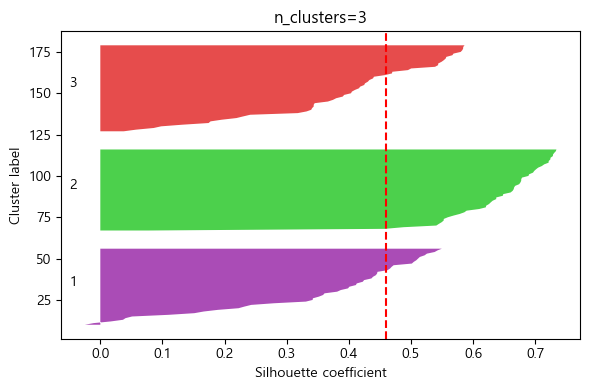

실루엣 계수 = 0.4599


In [ ]:
# 군집 수 = 3
fig, ax = plt.subplots(figsize=(6, 4))
score = silhouette_visualizer(df_raw_x, 3, ax)
plt.tight_layout()
plt.show()
print("실루엣 계수 =", format(round(score, 4)))

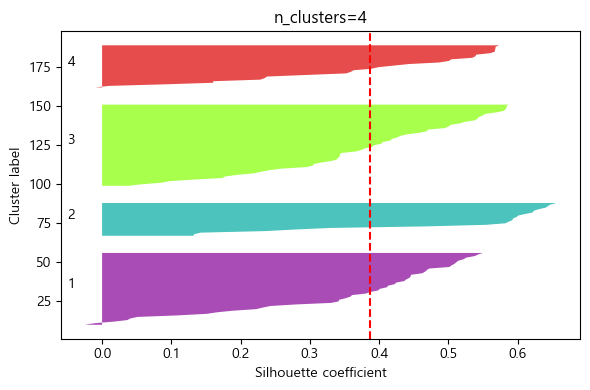

실루엣 계수 = 0.3869


In [ ]:
# 군집 수 = 4
fig, ax = plt.subplots(figsize=(6, 4))
score = silhouette_visualizer(df_raw_x, 4, ax)
plt.tight_layout()
plt.show()
print("실루엣 계수 =", format(round(score, 4)))

---

## End of 군집분석 실습

# 연관규칙 실습 (장바구니 구매이력 데이터)

---

## 📌 실습 개요

- **데이터**: 구매이력.CSV (변수: 2개, 자료: 105개)
- **목적**: 장바구니 ID별 구매 항목 자료를 이용하여 연관규칙 분석 실시 및 결과 해석
- **분석 절차**:
  - **STEP 1**: 데이터 구성하기
  - **STEP 2**: 연관규칙 분석 (지지도, 신뢰도, 향상도 산출)
  - **STEP 3**: 결론 도출

#### 패키지 불러오기

In [ ]:
# 데이터 구성: Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 전처리: 항목 값에 대한 index 생성
from mlxtend.preprocessing import TransactionEncoder
# 지지도 계산
from mlxtend.frequent_patterns import apriori
# 연관 규칙
from mlxtend.frequent_patterns import association_rules

---

## STEP 1: 데이터 구성하기

In [ ]:
# 구매이력 데이터 불러오기 (한글 포함 파일: encoding='cp949')
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\구매이력.csv", encoding="cp949")
df_raw.head(10)

,ID,PRODUCT
0,CS-102,양주
1,CS-102,양주
2,CS-103,소다
3,CS-103,크래커
4,CS-103,맥주
5,CS-104,크래커
6,CS-104,맥주
7,CS-106,양주
8,CS-106,크래커
9,CS-107,맥주


#### 데이터 구성 - 전처리

In [ ]:
# 고객 ID 리스트 생성 및 정렬
ID = list(set(df_raw["ID"]))
ID.sort()

# 고객ID별 상품 매칭
list_association = []
for i in ID:
    # ID별 구매 데이터 추출 (중복 제거)
    tmp_list = list(set(df_raw[df_raw["ID"] == i]["PRODUCT"]))
    tmp_list.sort()
    # ID별 구매 데이터를 리스트에 담기
    list_association.append(tmp_list)

# 리스트 출력
for row in list_association:
    print(row)

['양주']
['맥주', '소다', '크래커']
['맥주', '크래커']
['양주', '크래커']
['맥주', '콜라']
['맥주']
['맥주', '소다', '양주', '크래커']
['맥주']
['맥주', '콜라']
['맥주', '콜라']
['맥주', '양주', '콜라']
['맥주', '소다', '양주', '크래커']
['양주']
['맥주', '콜라']
['양주', '콜라']
['맥주', '크래커']
['맥주', '소다', '양주', '크래커']
['맥주', '소다', '양주', '크래커']
['맥주', '소다']
['소다', '양주', '크래커']
['크래커']
['양주', '콜라']
['맥주', '소다', '양주', '콜라', '크래커']
['양주', '콜라']
['맥주', '크래커']
['맥주', '소다', '크래커']
['맥주', '소다', '양주', '크래커']
['맥주']
['맥주', '콜라']
['양주', '콜라', '크래커']
['맥주', '콜라']
['맥주', '크래커']
['맥주']
['맥주', '소다', '양주', '크래커']
['맥주', '소다', '콜라']
['맥주', '콜라', '크래커']
['맥주', '양주']
['맥주', '콜라']
['맥주', '크래커']
['맥주', '소다', '양주', '크래커']
['소다', '양주', '콜라']
['맥주', '크래커']
['소다', '크래커']


In [ ]:
# Items 기준으로 포함 여부에 따라 True/False 로 변환
enc = TransactionEncoder()
df_raw_enc = enc.fit_transform(X=list_association)

# 함수 fit_transform 는 데이터를 행렬의 형태로 반환, pandas의 DataFrame 형태로 변환
df_asso = pd.DataFrame(df_raw_enc, columns=enc.columns_)

df_asso.head()

,맥주,소다,양주,콜라,크래커
0,False,False,True,False,False
1,True,True,False,False,True
2,True,False,False,False,True
3,False,False,True,False,True
4,True,False,False,True,False


---

## STEP 2: 연관규칙 분석

### 지지도, 신뢰도, 향상도 산출

#### 연관규칙 생성

In [ ]:
# 규칙 선택 최소 지지도
v_min_support = 0.2

# 연관규칙 생성 및 지지도 임계값 적용
df_freq = apriori(df_asso, min_support=v_min_support, use_colnames=True)  # 매개값 사용

# itemsets 항목 확인
df_freq.round(3)

,support,itemsets
0,0.744,(맥주)
1,0.349,(소다)
2,0.442,(양주)
3,0.372,(콜라)
4,0.512,(크래커)
5,0.279,"(맥주, 소다)"
6,0.233,"(맥주, 양주)"
7,0.256,"(콜라, 맥주)"
8,0.395,"(크래커, 맥주)"
9,0.233,"(소다, 양주)"


#### 연관규칙 선택

In [ ]:
# 향상도 기준: lift
df_asso_rule = association_rules(df_freq, metric="lift", min_threshold=1.3)
df_asso_rule.round(3)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(소다),(양주),0.349,0.442,0.233,0.667,1.509,0.078,1.674,0.518
1,(양주),(소다),0.442,0.349,0.233,0.526,1.509,0.078,1.375,0.604
2,(크래커),(소다),0.512,0.349,0.279,0.545,1.564,0.101,1.433,0.738
3,(소다),(크래커),0.349,0.512,0.279,0.800,1.564,0.101,2.442,0.554
4,"(크래커, 맥주)",(소다),0.395,0.349,0.233,0.588,1.686,0.095,1.581,0.673
5,"(맥주, 소다)",(크래커),0.279,0.512,0.233,0.833,1.629,0.090,2.930,0.535
6,(크래커),"(맥주, 소다)",0.512,0.279,0.233,0.455,1.629,0.090,1.322,0.790
7,(소다),"(크래커, 맥주)",0.349,0.395,0.233,0.667,1.686,0.095,1.814,0.625
8,"(크래커, 소다)",(양주),0.279,0.442,0.209,0.750,1.697,0.086,2.233,0.570
9,"(크래커, 양주)",(소다),0.256,0.349,0.209,0.818,2.345,0.120,3.581,0.771


In [ ]:
# 신뢰도 기준: confidence
df_asso_rule = association_rules(df_freq, metric="confidence", min_threshold=0.7)
df_asso_rule.round(3)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(소다),(맥주),0.349,0.744,0.279,0.800,1.075,0.019,1.279,0.107
1,(크래커),(맥주),0.512,0.744,0.395,0.773,1.038,0.015,1.126,0.076
2,(소다),(크래커),0.349,0.512,0.279,0.800,1.564,0.101,2.442,0.554
3,"(크래커, 소다)",(맥주),0.279,0.744,0.233,0.833,1.120,0.025,1.535,0.148
4,"(맥주, 소다)",(크래커),0.279,0.512,0.233,0.833,1.629,0.090,2.930,0.535
5,"(크래커, 소다)",(양주),0.279,0.442,0.209,0.750,1.697,0.086,2.233,0.570
6,"(크래커, 양주)",(소다),0.256,0.349,0.209,0.818,2.345,0.120,3.581,0.771
7,"(소다, 양주)",(크래커),0.233,0.512,0.209,0.900,1.759,0.090,4.884,0.562


---

## STEP 3: 결론 도출

### 주요 연관규칙 해석

In [ ]:
# 향상도 기준 상위 규칙 정렬 (lift 내림차순)
df_result = association_rules(df_freq, metric="lift", min_threshold=1.0)
df_result = df_result[["antecedents", "consequents", "support", "confidence", "lift"]]
df_result = df_result.sort_values("lift", ascending=False)
df_result.round(3)

,antecedents,consequents,support,confidence,lift
17,"(크래커, 양주)",(소다),0.209,0.818,2.345
20,(소다),"(크래커, 양주)",0.209,0.600,2.345
19,(크래커),"(소다, 양주)",0.209,0.409,1.759
18,"(소다, 양주)",(크래커),0.209,0.900,1.759
21,(양주),"(크래커, 소다)",0.209,0.474,1.697
16,"(크래커, 소다)",(양주),0.209,0.750,1.697
10,"(크래커, 맥주)",(소다),0.233,0.588,1.686
15,(소다),"(크래커, 맥주)",0.233,0.667,1.686
12,"(맥주, 소다)",(크래커),0.233,0.833,1.629
13,(크래커),"(맥주, 소다)",0.233,0.455,1.629


#### 해석 기준

| 지표 | 의미 | 기준 |
|------|------|------|
| **지지도 (support)** | 두 항목이 함께 구매된 비율 | 높을수록 빈번한 조합 |
| **신뢰도 (confidence)** | A를 샀을 때 B도 살 확률 | 1에 가까울수록 신뢰성 ↑ |
| **향상도 (lift)** | 연관규칙의 유용성 | **1 초과**면 양의 연관 관계 |

- **향상도 > 1**: A와 B는 서로 양의 연관관계 → 함께 구매될 가능성 높음
- **향상도 = 1**: 독립 관계 → 연관성 없음
- **향상도 < 1**: 음의 연관관계 → 함께 구매될 가능성 낮음

## End of 연관규칙